<a href="https://colab.research.google.com/github/jigarpatel18/programming-projects/blob/main/Group_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group MiniProject

#Topic Overview

Artificial intelligence has become deeply embedded in the daily lives of college students, especially those studying computer science and data science. From using ChatGPT to debugging code, to encountering AI-generated images and videos on social media, students interact with AI-generated content essentially all the time. As AI tools become more sophisticated, the ability to recognize and evaluate AI-generated content is becoming an important skill. This project investigates how students interact with and perceive AI-generated content and what factors shape how critically they engage with it. Using data collected from the survey distributed across CS 111, CS 105, and CS 010C at UCR, we explored the patterns in AI tool usage, social media exposure to AI content, and student willingness to verify whether content they encounter is AI-generated. Our core question is:

**How confident are students in detecting AI-generated text, and what factors influence that confidence?**

Because our dataset does not contain a direct measure of detection confidence, we use verification likelihood as our primary source. A student who feels confident in their ability to detect AI content is more likely than not to attempt verification compared to someone who feels incapable of doing so. Through this project, we aim to identify the key factors that can predict this behavior.



#What Data Do We Have?

Our dataset comes from a survey that was given to students across CS 111, CS 105, and CS 010C at UCR. The survey was designed by students in CS 105 as a part of a mini-project. The dataset contains 226 responses and 137 columns which covers topics such as: student demographics (class standing, major, age, ethnicity, and GPA), AI tool usage (which LLMs students use and how frequently), social media habits (primary platform and frequency of encountering AI generated content), academic behavior (how often students use AI for different subjects and coursework), attitudes and perceptions (how students feel about AI on their feeds and their ethical concerns about AI content, and the likelihood that they verify AI generated content), and confidence measures (self reported confidence in completing tasks without AI). Before analysis, we cleaned the dataset by converting the Timestamp column to a datetime format and removing rows with more than 20 missing values to reduce noise in our results. After cleaning, we were able to keep all 226 responses.





#What Would We Like To Know?

Our main question is, how confident are students in detecting AI-generated text, and what factors influence that confidence? Since our dataset does not directly ask students how confident they are in detecting AI-generated text, we used verification likelihood as a behavioral proxy. We treated this as a stand-in for detection confidence based on the assumption that a student who feels capable of spotting AI content is more likely to actually try. We aim to answer the following specific sub-questions through our visualizations and statistical tests.
1. When students need help, do they reach for AI first or traditional resources?
2. What types of AI-generated content are students most exposed to on social media?
3. Which AI tools are students actually using and how often?
4. For which subjects are students relying on AI the most, and does that change as they progress academically?
5. Across verification likelihood, ethical concern, attitude toward AI, and AI usage, how do these factors differ between Freshmen and Seniors?
6. Does the social media platform a student uses most affect how likely they are to verify AI content?
7. Does caring about the ethics of AI content actually make students more likely to verify what they see?
8. Does how a student feels about AI on their feed predict whether they will bother checking if it is real?



# Data Upload and Cleaning

The dataset we are using comes from a survey we sent to a couple CS classes (CS 111, CS 105, CS 010C).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the survey data
df = pd.read_csv("CS105_Survey.csv")

# Clean the data
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
threshold = df.shape[1] - 20
df = df.dropna(thresh=threshold)
df.reset_index(drop=True, inplace=True)

# Export cleaned data as a separate CSV file
df.to_csv("CS105_Survey_Cleaned.csv", index=False)

# Preview 5 relevant columns
cols_to_preview = [
    'What is your current class standing?',
    'What is your main social media platform?',
    'How likely are you to verify if the content you see on social media is AI-generated or not?',
    'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)',
    'How do you feel about AI-generated content on your social media feed?'
]

df[cols_to_preview].head()

,What is your current class standing?,What is your main social media platform?,How likely are you to verify if the content you see on social media is AI-generated or not?,"How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)",How do you feel about AI-generated content on your social media feed?
0,Junior,NaN,NaN,NaN,NaN
1,Sophomore,NaN,NaN,NaN,NaN
2,Sophomore,Instagram,4.0,5.0,1.0
3,Junior,TikTok,3.0,5.0,1.0
4,Senior,Instagram,3.0,5.0,1.0


# EDA (Exploratory Data Analysis)

Some important things we want to look at before answering our questions are any strong correlations or interesting insights.

- When students need help, do they reach for AI first or traditional resources?
- What types of AI-generated content are students most exposed to on social media?
- Which AI tools are students actually using and how often?
- For which subjects are students relying on AI the most, and does that change as they progress academically?
- Across verification likelihood, ethical concern, attitude toward AI, and AI usage, how do these factors differ between Freshmen and Seniors?
- Does the social media platform a student uses most affect how likely they are to verify AI content?
- Does caring about the ethics of AI content actually make students more likely to verify what they see?
- Does how a student feels about AI on their feed predict whether they will bother checking if it is real?




**1. When students need help, do they reach for AI first or traditional resources?**

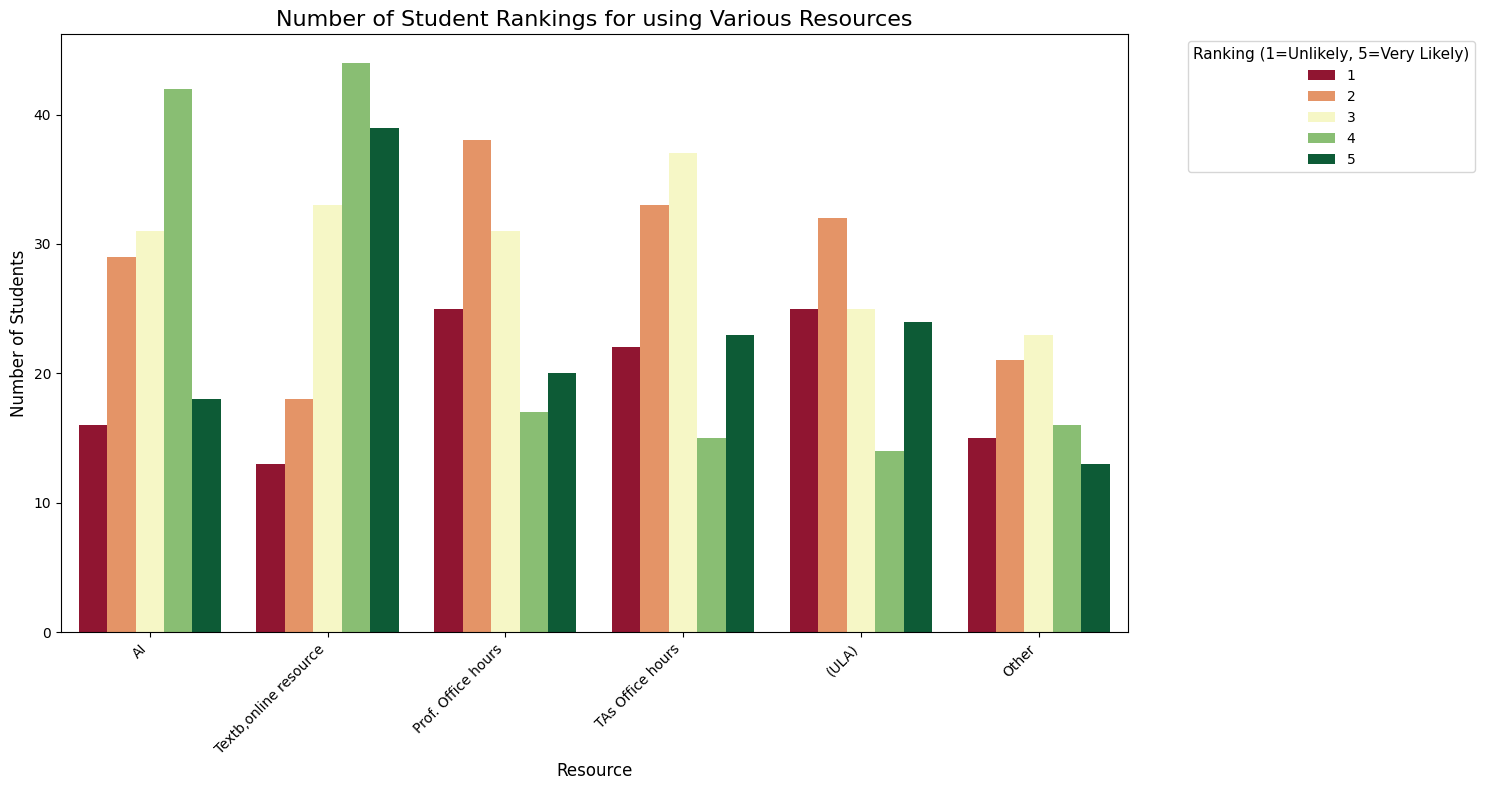

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

resource_col = [
    "When you encounter a problem that you don’t know how to solve or are unfamiliar with, what resource(s) do you use? [Generative AI]",
    "When you encounter a problem that you don’t know how to solve or are unfamiliar with, what resource(s) do you use? [Textbooks, online resources]",
    "When you encounter a problem that you don’t know how to solve or are unfamiliar with, what resource(s) do you use? [Professor's Office hours]",
    "When you encounter a problem that you don’t know how to solve or are unfamiliar with, what resource(s) do you use? [TAs' Office hours]",
    "When you encounter a problem that you don’t know how to solve or are unfamiliar with, what resource(s) do you use? [Undergraduate Learning Assistants (ULA)]",
    "When you encounter a problem that you don’t know how to solve or are unfamiliar with, what resource(s) do you use? [Other]",
]

display_name = [
    "AI",
    "Textb,online resource",
    "Prof. Office hours",
    "TAs Office hours",
    "(ULA)",
    "Other"
]

df_resource = df[resource_col].copy()
df_resource.columns = display_name

df_melted = df_resource.melt(var_name='Resource', value_name='Ranking')
df_melted['Ranking'] = pd.to_numeric(df_melted['Ranking'], errors='coerce')
df_melted.dropna(subset=['Ranking'], inplace=True)
df_melted['Ranking'] = df_melted['Ranking'].astype(int)
df_melted = df_melted[df_melted['Ranking'].isin(range(1, 6))]


proportions = (df_melted.groupby(['Resource', 'Ranking']).size().reset_index(name='Count'))

plt.figure(figsize=(15, 8))

sns.barplot(
    data=proportions,
    x='Resource',
    y='Count',
    hue='Ranking',
    palette='RdYlGn',
    order=display_name
)

plt.title('Number of Student Rankings for using Various Resources', fontsize=16)
plt.xlabel('Resource', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title='Ranking (1=Unlikely, 5=Very Likely)', title_fontsize='11', fontsize='10', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

**Looking at the graph, we can see that students are more likely to refer to Generative AI or textbooks/ online resources rather than professors' or TAs' office hours. Generative AI ranks highly as a first-choice resource across the student population, sitting alongside or above traditional academic resources in terms of how frequently students turn to it first. This is a good look into how quickly students are to choose a resource that quickly can guide them to the right solution rather than have to wait for office hours before their questions are answered. When using these insights for our main question of whether students can detect AI content when they come across it, we can move closer to the idea that, because students are quicker to use AI and online resources, they can have a good sense of what AI-generated content and regular, non-AI-generated content looks like. This could show that they know when the content they look at is AI or not, but we cannot say definitively that this is true.**





**What types of AI-generated content are students most exposed to on social media?**

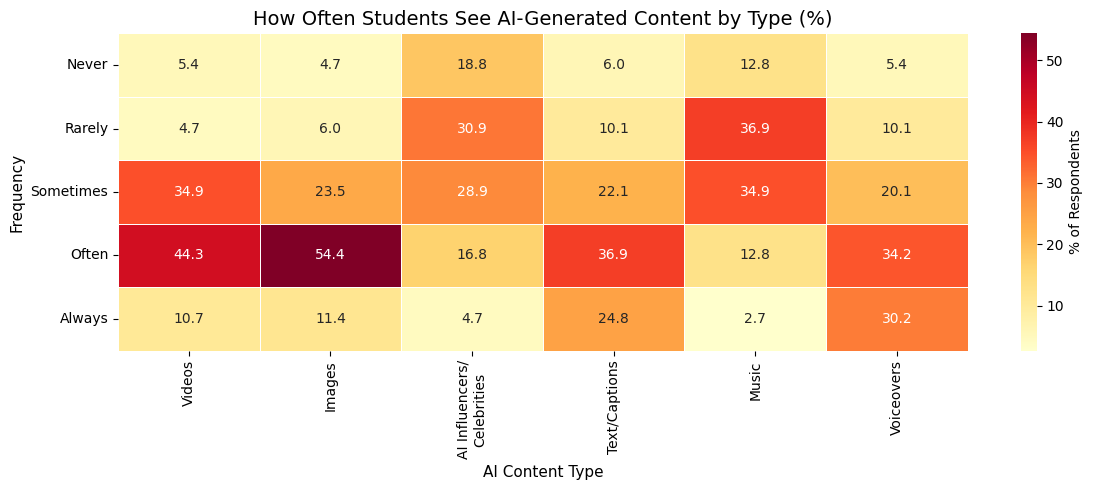

In [ ]:
# Grab all columns about AI content frequency
freq_cols = [c for c in df.columns if 'frequently do you see AI' in c]
content_labels = [c.split('[')[-1][:-1].strip() for c in freq_cols]

order_map = {'Never': 1, 'Rarely': 2, 'Sometimes': 3, 'Often': 4, 'Always': 5}

freq_df = df[freq_cols].copy()
freq_df.columns = content_labels
freq_numeric = freq_df.apply(lambda col: col.map(order_map))

freq_pct = pd.DataFrame()
for col in freq_numeric.columns:
    counts = freq_numeric[col].value_counts().reindex([1,2,3,4,5], fill_value=0)
    freq_pct[col] = counts / counts.sum() * 100

freq_pct.index = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']


fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(freq_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% of Respondents'}, ax=ax)
ax.set_title('How Often Students See AI-Generated Content by Type (%)', fontsize=14)
ax.set_xlabel('AI Content Type', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.tick_params(axis='y', rotation=0)
ax.set_xticklabels(['Videos', 'Images', 'AI Influencers/\nCelebrities', 'Text/Captions', 'Music', 'Voiceovers'], fontsize=10)
plt.tight_layout()
plt.show()

**This visualization expands beyond academics and into students' social media lives. It shows how frequently students see different types of AI-generated content like videos, images, and text on their feeds. Looking at the results, Videos and Images stand out as the most commonly seen types of AI content, with the majority of students reporting they see them often or always. Text and Captions follow closely behind, while AI influencers and Music are much lower frequency, suggesting that students are less exposed to or less aware of those forms of AI content. The reason this matters for our main question is that detection confidence is built through exposure. A student who sees AI generated contetn constantly has more opportunities to develop an eye for it. However, high exposure is not directly correlated to high confidence, as many students are passively scrolling without looking in depth into the content they see. This exposure might not give them more of an advantage in their skills in AI detection than someone who does not typically see AI daily.**

**Which AI tools are students actually using and how often?**

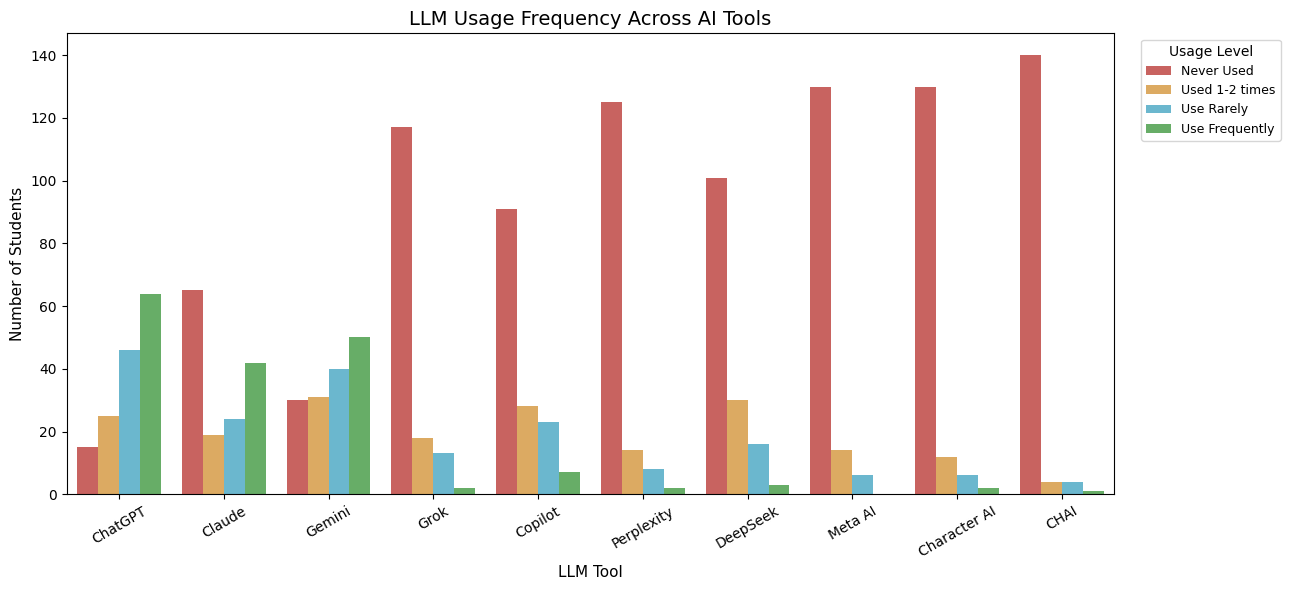

In [ ]:
# Grab all LLM usage columns
llm_cols = [c for c in df.columns if 'Large Learning Models' in c]
llm_labels = [c.split('[')[-1][:-1].strip() for c in llm_cols]

llm_df = df[llm_cols].copy()
llm_df.columns = llm_labels

# Melt to long format so seaborn can plot it
llm_melted = llm_df.melt(var_name='LLM', value_name='Usage').dropna()

usage_order = ['Never Used', 'Used 1-2 times', 'Use Rarely', 'Use Frequently']

fig, ax = plt.subplots(figsize=(13, 6))
sns.countplot(data=llm_melted, x='LLM', hue='Usage',
              hue_order=usage_order,
              palette=['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'])
ax.set_title('LLM Usage Frequency Across AI Tools', fontsize=14)
ax.set_xlabel('LLM Tool', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Usage Level', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Here, we looked into what AI tools students are using and how often. ChatGPT is dominating this sector with the  Use Frequently responses across all the tools. Tools like Gemini and Copilot show moderate adoption, while the majority of students have never used tools like CHAI, DeepSeek, or Perplexity at all. This is directly relevant to our main question because students have a very narrow frame of reference for what AI-generated texts look like since they are only used to just one AI's writing style. A student who only knows ChatGPT's patterns may feel confident in detecting that the material is AI, but they could have a differing opinion on text generated by AI like Claude or Gemini. As AI tools diversify and become harder to distinguish from each other and especially human writing, this narrows familiarity because of a significant gap in students' ability to reliably detect AI-generated content.**



**For which subjects are students relying on AI the most, and does that change as they get more experienced?**

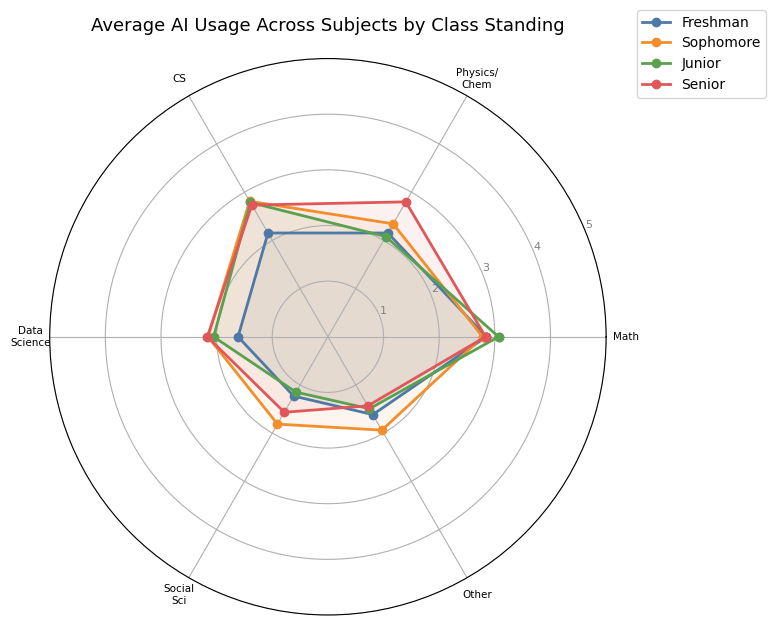

In [ ]:
# Grab AI coursework usage columns
ai_mat_cols = [c for c in df.columns if 'use AI to help' in c]
subjects = ['Math', 'Physics/Chem', 'CS', 'Data Science', 'Social Sci', 'Other']
standings = ['Freshman', 'Sophomore', 'Junior', 'Senior']

radar_df = df[ai_mat_cols + ['What is your current class standing?']].copy()
radar_df.columns = subjects + ['Standing']
radar_df = radar_df[radar_df['Standing'].isin(standings)]

for col in subjects:
    radar_df[col] = pd.to_numeric(radar_df[col], errors='coerce')

means = radar_df.groupby('Standing')[subjects].mean()

N = len(subjects)
angles = [n / N * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, standing in enumerate(standings):
    vals = means.loc[standing].tolist() + [means.loc[standing].tolist()[0]]
    ax.plot(angles, vals, 'o-', linewidth=2, color=colors[i], label=standing)
    ax.fill(angles, vals, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Math', 'Physics/\nChem', 'CS', 'Data\nScience', 'Social\nSci', 'Other'], fontsize=7.5)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=8, color='grey')
ax.set_title('Average AI Usage Across Subjects by Class Standing', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

**This visualization asks whether AI reliance changes as students progress through their academic careers. The radar chart shows average AI usage across six subjects for each class year simultaneously. If detection confidence grows with experience, we would expect Seniors to show a different usage profile than Freshmen, maybe more targeted usage instead of a broader one. Looking at the actual results, all four class standings show a similar overall shape, with AI usage being the highest for CS and Math across every year, and the lowest for Social Sciences and Other. This tells us that AI reliance is concentrated in technical subjects regardless of how far along a student is in their academic career. However, Sophomores show the largest overall profile with notably higher usage across most subjects compared to the other three years. Freshman show the flattest and smallest profile, suggesting they have not yet fully integrated AI into their academic workflow. Juniors and Seniors sit in between, showing moderate, consistent usage across subjects. In the context of our main question, this is an important finding. The fact that sophomores show the highest AI usage, but our other visualizations suggest Freshmen are most likely to verify AI content, tells us that AI usage and detection confidence are not moving in the same direction as students progress academically. More AI usage does not appear to be building stronger detection habits; it seems like the more they use it, the less likely they are to question it.**




**Across verification, ethical concern, attitude, and AI usage, how do these factors differ between Freshmen and Seniors?**

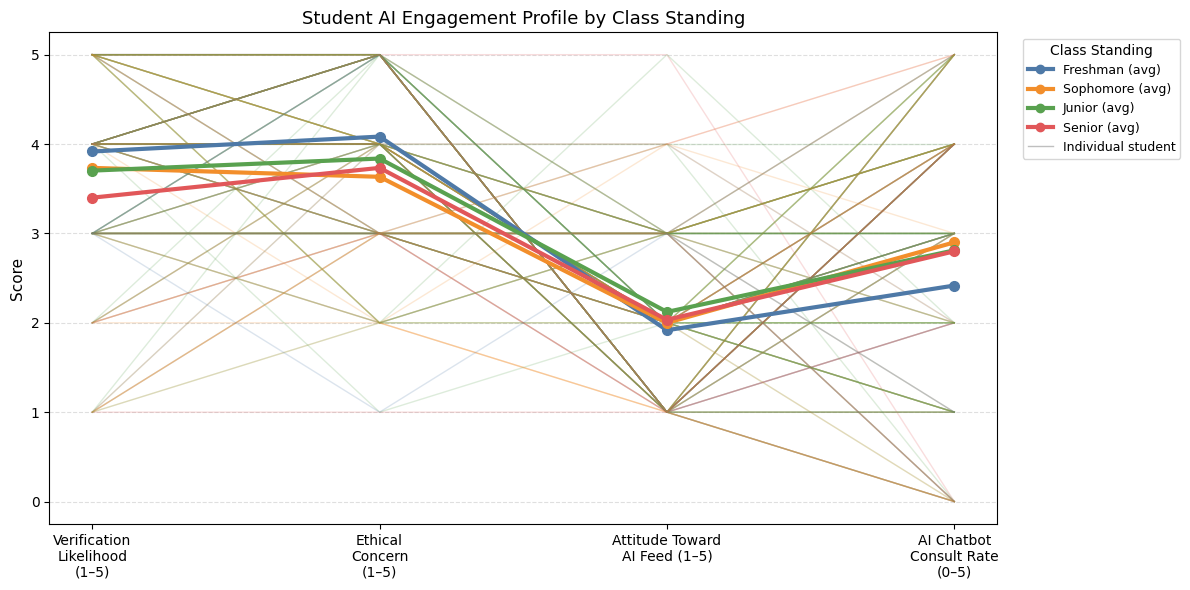

In [ ]:
verify = 'How likely are you to verify if the content you see on social media is AI-generated or not?'
ethical = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)'
feel = 'How do you feel about AI-generated content on your social media feed?'
consult = [c for c in df.columns if 'consult each source' in c and 'AI Chatbot' in c][0]
standing = 'What is your current class standing?'

cols = ['Verify', 'Ethical', 'Feel', 'AI_Consult']
col_labels = ['Verification\nLikelihood\n(1–5)', 'Ethical\nConcern\n(1–5)',
              'Attitude Toward\nAI Feed (1–5)', 'AI Chatbot\nConsult Rate\n(0–5)']

pc_df = df[[standing, verify, ethical, feel, consult]].copy()
pc_df.columns = ['Standing'] + cols
pc_df = pc_df[pc_df['Standing'].isin(['Freshman', 'Sophomore', 'Junior', 'Senior'])]
pc_df[cols] = pc_df[cols].apply(pd.to_numeric, errors='coerce')
pc_df = pc_df.dropna().reset_index(drop=True)

color_map = {'Freshman': '#4e79a7', 'Sophomore': '#f28e2b',
             'Junior': '#59a14f', 'Senior': '#e15759'}

fig, ax = plt.subplots(figsize=(12, 6))

# Draw faint line for every individual student
for _, row in pc_df.iterrows():
    ax.plot(range(len(cols)), [row[c] for c in cols],
            color=color_map[row['Standing']], alpha=0.2, linewidth=1.0)

# Draw bold line for each class standing average
means_pc = pc_df.groupby('Standing')[cols].mean()
for s, color in color_map.items():
    if s in means_pc.index:
        ax.plot(range(len(cols)), means_pc.loc[s],
                color=color, linewidth=3,
                marker='o', markersize=7, zorder=5)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Student AI Engagement Profile by Class Standing', fontsize=13)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# Manual legend explaining both line types
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='#4e79a7', linewidth=3, marker='o', label='Freshman (avg)'),
    Line2D([0], [0], color='#f28e2b', linewidth=3, marker='o', label='Sophomore (avg)'),
    Line2D([0], [0], color='#59a14f', linewidth=3, marker='o', label='Junior (avg)'),
    Line2D([0], [0], color='#e15759', linewidth=3, marker='o', label='Senior (avg)'),
    Line2D([0], [0], color='grey', linewidth=1, alpha=0.5, label='Individual student'),
]

ax.legend(handles=legend_elements, title='Class Standing',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

**This visualization serves as a bridge between four different variables: the verification likelihood, ethical concern, attitude towards AI content, and AI chatbot consult rate for each class standing. The bold line shows each group's average profile across all four dimensions at once, while the faint lines are the individual students. Looking at the averages, Freshmen show a notably different profile compared to upperclassmen; they tend to have higher certification likelihood and ethical concern but lower AI chatbot reliance. Seniors and Juniors show the opposite pattern with higher AI chatbot reliance but comparatively lower verification likelihood. This is a counterintuitive finding since you would expect students who use AI more to be the ones who would detect it, but the data suggests otherwise. In the context of the main question, this tells us that heavy AI usage and detection confidence do not go hand in hand. The students who rely on Ai the most are not the ones most likely to verify AI content, suggesting that familiarity with AI tools may actually reduce critical engagement rather than build it.**



**Does the social media platform a student uses most affect how likely they are to verify AI content? (Box and Whisker Plot)**

<Figure size 1200x600 with 0 Axes>

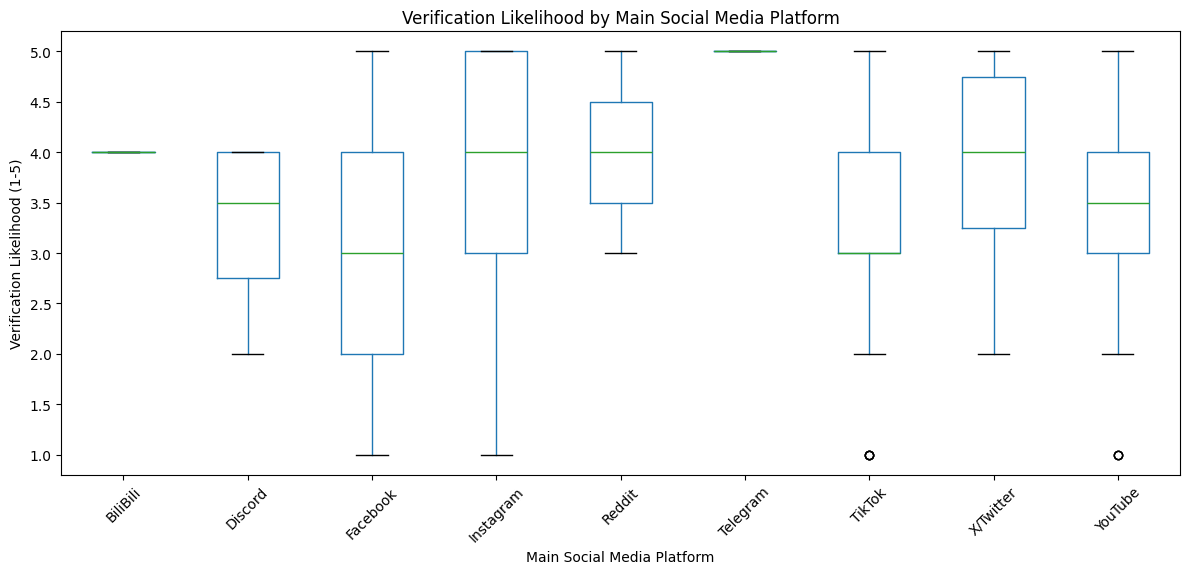

In [ ]:
platform_col = "What is your main social media platform?"
verify_col = "How likely are you to verify if the content you see on social media is AI-generated or not?"

#keep only rows with valid responses
plot_df = df[[platform_col, verify_col]].dropna()
#convert verification likelihood to numeric (1-5 scale)
plot_df[verify_col] = pd.to_numeric(plot_df[verify_col], errors="coerce")
plot_df = plot_df.dropna()


plt.figure(figsize=(12, 6))
order = plot_df.groupby(platform_col)[verify_col].median().sort_values().index
plot_df.boxplot(column=verify_col, by=platform_col, figsize=(12,6), grid=False, showfliers=True)

plt.title("Verification Likelihood by Main Social Media Platform")
plt.suptitle("")
plt.xlabel("Main Social Media Platform")
plt.ylabel("Verification Likelihood (1-5)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**This box plot compares verification likelihood across all social media platforms reported by students in our survey. The median verification score shown by the green line in each box varies noticeably across platforms. Reddit stands out with one of the highest medians and a relatively tight interquartile range, suggesting that Reddit usersa re consistently more likely to verify AI content, which makes sense given that Reddit is a text heavy platofrm wheree users are accustomed to questioning the accuracy of information. Instagram also shows a high media consistency with the idea that heavy exposure to AI-generated images and videos on a visual platform encourages more active verification habits. TikTok, on the other hand, shows a lower median despite being one of the most AI-saturated platforms, which may suggest that the fast scrolling nature of the app makes verification harder even though exposure is higher. Platforms such as BiliBili and Telegram have very few respondents, so their boxes should be interpreted with caution. In the context of the main question, this tells us that the platform a student uses most does appear to shape their verification behavior, but not always in the direction that is expected. High AI exposure does not automatically produce high verification likelihood; the nature of how content is consumed matters just as much as how much there is.**



**Does caring about AI ethics actually make students more likely to verify what they see? (Scatter Plot/Box Plot)**

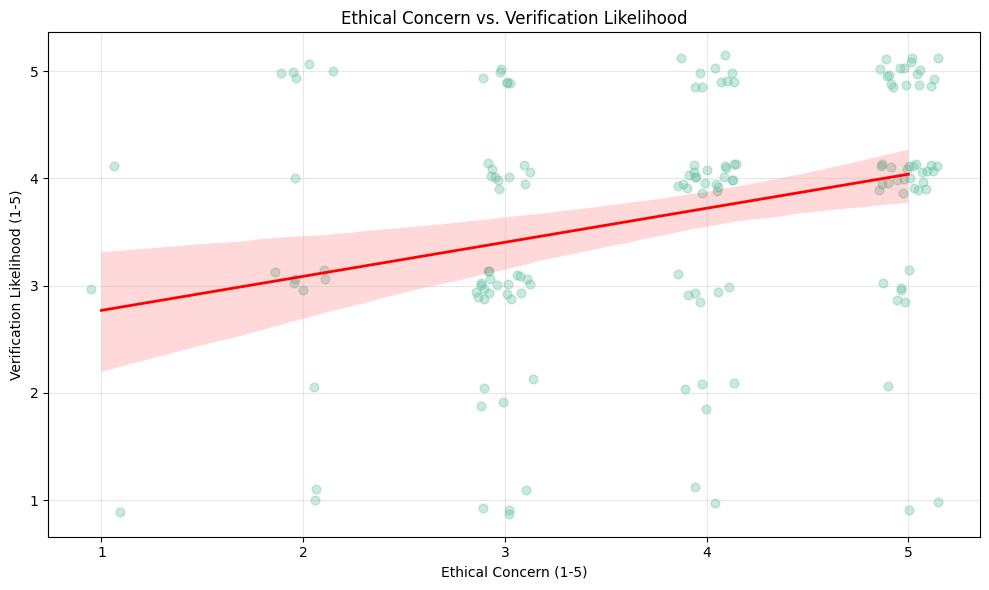

In [ ]:
df = pd.read_csv("CS105_Survey.csv")
verify_col = "How likely are you to verify if the content you see on social media is AI-generated or not?"
ethics_col = "How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)"
scatter_df = df[[verify_col, ethics_col]].copy()
scatter_df[verify_col] = pd.to_numeric(scatter_df[verify_col], errors="coerce")
scatter_df[ethics_col] = pd.to_numeric(scatter_df[ethics_col], errors="coerce")
scatter_df = scatter_df.dropna()

plt.figure(figsize=(10,6))
sns.regplot(data=scatter_df, x=ethics_col, y=verify_col, x_jitter=0.15, y_jitter=0.15, scatter_kws={"alpha": 0.35, "s":40, "color":sns.color_palette("Set2")[0]}, line_kws={"color": "red", "linewidth": 2})

plt.xlabel("Ethical Concern (1-5)")
plt.ylabel("Verification Likelihood (1-5)")
plt.title("Ethical Concern vs. Verification Likelihood")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**This scatter plot shows the likelihood of students checking if they have ethical concerns about whether the content is AI-generated or not. The x-axis measures the level of concern on a scale of (1-5), and the y-axis measures the likelihood of verification on a scale of (1-5). Because I used jitter, the points are spread out, but the pattern of the points clearly shows that students with lower concerns are more likely to cluster in the lower verification. On the contrary, students with greater ethical concerns tend to gather in the higher chance of verification. Meaning that the higher the ethical concerns are, the more likely to check or verify if the content is AI-generated or not. Therefore, there is a modest positive relationship between students' verification and ethical concerns. In the context of our main question, this positive relationship suggests that ethical concern is one of the factors that influence detection confidence. However, the widespread points around the trend line are an important detail telling us that ethical concern alone does not fully explain verification behavior. Some students with very great ethical concern still show low verification likelihood, meaning other factors such as platform environment, attitude toward AI, and academic experience are also shaping whether a student feels confident enough to actively check for AI-generated content.**





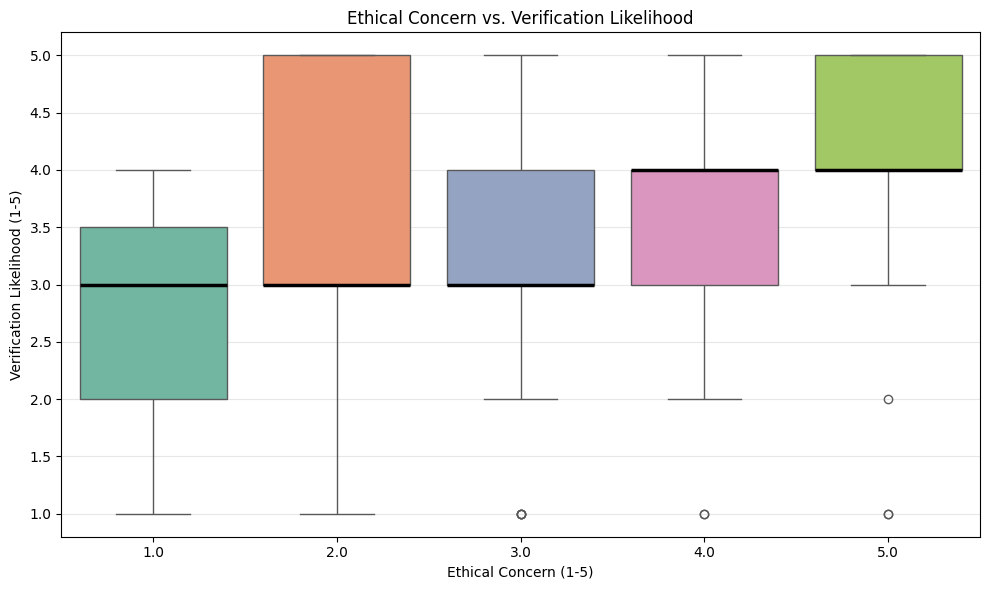

In [ ]:
df = pd.read_csv("CS105_Survey.csv")
verify_col = "How likely are you to verify if the content you see on social media is AI-generated or not?"
ethics_col = "How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)"

box_df = df[[verify_col, ethics_col]].copy()
box_df[verify_col] = pd.to_numeric(box_df[verify_col], errors="coerce")
box_df[ethics_col] = pd.to_numeric(box_df[ethics_col], errors="coerce")
box_df = box_df.dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=box_df,
    x=ethics_col,
    y=verify_col,
    hue=ethics_col,
    palette="Set2",
    legend=False,
    medianprops=dict(color="black", linewidth=2.5)
)

plt.xlabel("Ethical Concern (1-5)")
plt.ylabel("Verification Likelihood (1-5)")
plt.title("Ethical Concern vs. Verification Likelihood")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**The box plot compares the likelihood of the verification across the different levels of ethical concerns about AI generated contents. Each box represents a different level of ethical concern on the scale of 1-5. This shows the median and the whole box increases as the ethical concern increases; therefore, the relationship is consistent. There are a few outliers at the bottom of the box, which represent unusual behavior of students who have great concern but low verification tendency. However, they do not disrupt the pattern of student behavior. Overall, this visualization shows that students who have a great concern about AI ethics are more likely to verify whether the content is AI-generated or not. On the contrary, students who are less likely to be concerned about AI ethics are less likely to verify whether the content is generated using AI or not. In the context of our main question, this suggests that ethical awarenes sis one of the key factors influencing detection confidence. Students who care about the implications of AI generated cotnent are motivated to actively verify what they see, making ethical concern a predictor of critical engagement with AI content.**





**Does how a student feels about AI on their feed predict whether they will bother checking if it is real? (Stacked Bar)**

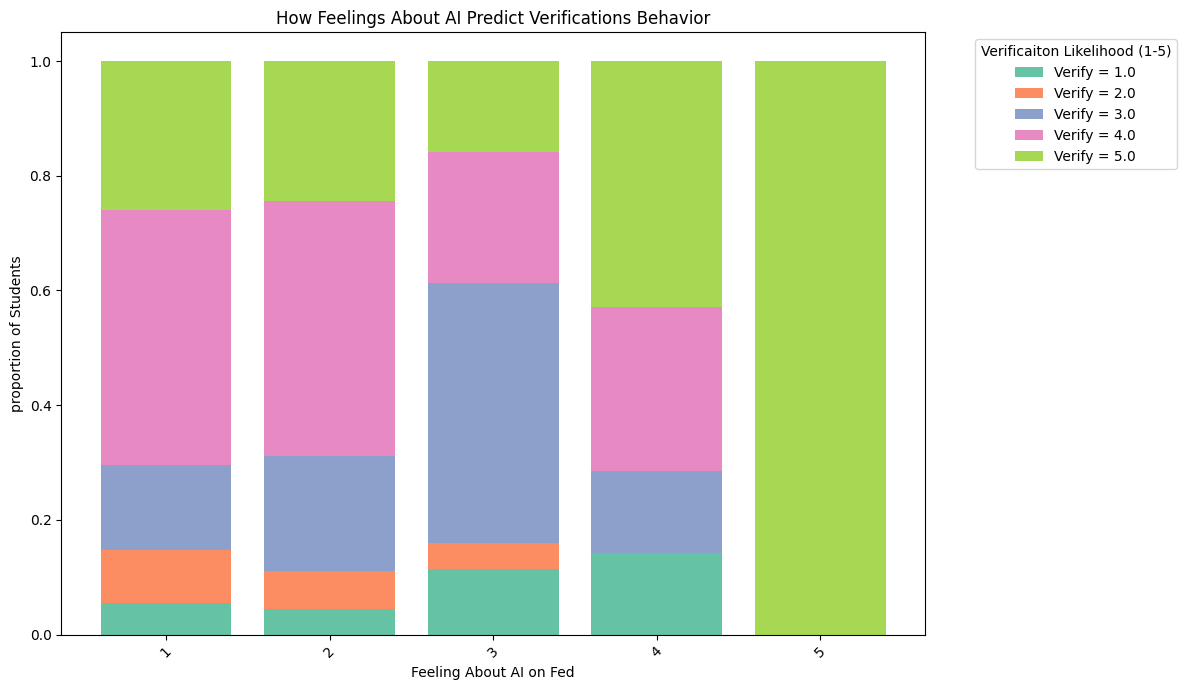

In [ ]:
feel_col = "How do you feel about AI-generated content on your social media feed?"
verify_col = "How likely are you to verify if the content you see on social media is AI-generated or not?"

stack_df = df[[feel_col, verify_col]].copy()
stack_df[verify_col] = pd.to_numeric(stack_df[verify_col], errors="coerce")
stack_df = stack_df.dropna()
ct = pd.crosstab(stack_df[feel_col], stack_df[verify_col])
ct_prop = ct.div(ct.sum(axis=1), axis=0)

num_cols = len(ct_prop.columns)
colors = sns.color_palette("Set2", num_cols)
plt.figure(figsize=(12,7))
bottom = None
for i, col in enumerate(ct_prop.columns):
    if bottom is None:
      plt.bar(ct_prop.index, ct_prop[col],
              label=f"Verify = {col}", color=colors[i])
      bottom = ct_prop[col]
    else:
      plt.bar(ct_prop.index, ct_prop[col], bottom=bottom,
              label=f"Verify = {col}", color=colors[i])
      bottom += ct_prop[col]

plt.title("How Feelings About AI Predict Verifications Behavior")
plt.xlabel("Feeling About AI on Fed")
plt.ylabel("proportion of Students")
plt.xticks(rotation=45)
plt.legend(title="Verificaiton Likelihood (1-5)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**This visualization shows that students who feel negatively about AI content on their social media feed tend to have a higher proportion of high verification scores, while students who feel positively tend to cluster toward lower verification scores. At first glance, this seems to make sense. If you dislike AI content, you would be more motivated to check for it. However, this is actually one of the more counterintuitive findings in the project. Students with very negative attitudes are not the most likely to verify; students with neutral attitudes show some of the strongest verification behavior. This suggests that rejection of AI content does not necessarily produce more vigilant detection habits. Instead, students who engage with AI content with a more open and curious mindset appear to be more deliberate about checking whether what they see is real. In the context of our main question, this tells us that attitude toward AI on social media is a factor in detection confidence, but not in the straightforward way that is expected. Disliking AI does not make you better at detecting it. Active engagement, regardless of whether that attitude is positive or negative, appears to be what drives verification behavior.**



# Chi Squared

For out statistical tests, we are going to do a chi squared test

Hypothesis:
H₀: There is no association between how students feel about AI-generated content on their feed and their likelihood of verifying whether content is AI-generated.
Hₐ: Students' feelings about AI-generated content on their feed are associated with their likelihood of verifying whether content is AI-generated.

In [ ]:
from scipy.stats import chi2_contingency

feel_col = "How do you feel about AI-generated content on your social media feed?"
verify_col = "How likely are you to verify if the content you see on social media is AI-generated or not?"

# Create a contingency table
contingency_table = pd.crosstab(df[feel_col], df[verify_col])

# Perform the Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:\n", expected)

Chi-squared statistic: 26.5206
P-value: 0.0471
Degrees of freedom: 16
Expected frequencies:
 [[ 3.90789474  3.55263158 13.5        19.89473684 13.14473684]
 [ 3.25657895  2.96052632 11.25       16.57894737 10.95394737]
 [ 3.18421053  2.89473684 11.         16.21052632 10.71052632]
 [ 0.50657895  0.46052632  1.75        2.57894737  1.70394737]
 [ 0.14473684  0.13157895  0.5         0.73684211  0.48684211]]


The Chi-squared test examines whether there is a significant association between students' feelings about AI-generated content on their social media feed and their likelihood to verify that content. A low p-value (typically < 0.05) would suggest a statistically significant relationship, meaning that the observed frequencies in the contingency table are unlikely to have occurred by chance if there were no association.

The chi-squared test yielded χ² = 26.52, p = 0.047, with 16 degrees of freedom. Since the p-value is below 0.05, we reject the null hypothesis and conclude that there is a statistically significant association between how students feel about AI-generated content on their feed and their likelihood of verifying whether that content is AI-generated.

## Hypothesis 1: Ethical Concern is Positively Correlated with Verification Likelihood

**Hypothesis:** Students who are more concerned about the ethical implications of AI-generated content (e.g., misinformation, copyright) are more likely to verify whether the content they see is AI-generated.

**Null Hypothesis (H₀):** There is no correlation between ethical concern and verification likelihood.

**Alternative Hypothesis (H₁):** There is a positive correlation between ethical concern and verification likelihood.

**Statistical Test — Spearman Rank Correlation:**  
We use the Spearman rank correlation because both variables (ethical concern and verification likelihood) are measured on ordinal Likert scales (1–5). Spearman correlation does not assume a normal distribution and is robust to outliers, making it more appropriate than Pearson correlation for ordinal survey data.

We set a significance level of α = 0.05.

In [ ]:
from scipy import stats
import pandas as pd

verify_col = 'How likely are you to verify if the content you see on social media is AI-generated or not?'
ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)'

h1_df = df[[verify_col, ethics_col]].copy()
h1_df[verify_col] = pd.to_numeric(h1_df[verify_col], errors='coerce')
h1_df[ethics_col] = pd.to_numeric(h1_df[ethics_col], errors='coerce')
h1_df = h1_df.dropna()

corr, p_value = stats.spearmanr(h1_df[ethics_col], h1_df[verify_col])

print(f'Spearman Correlation Coefficient: {corr:.4f}')
print(f'P-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nResult: p-value ({p_value:.4f}) < alpha ({alpha}) -> Reject the null hypothesis.')
    print('There is a statistically significant positive correlation between ethical concern and verification likelihood.')
else:
    print(f'\nResult: p-value ({p_value:.4f}) >= alpha ({alpha}) -> Fail to reject the null hypothesis.')
    print('There is no statistically significant correlation.')


Spearman Correlation Coefficient: 0.3148
P-value: 0.0001

Result: p-value (0.0001) < alpha (0.05) -> Reject the null hypothesis.
There is a statistically significant positive correlation between ethical concern and verification likelihood.


**Interpretation:**  
The Spearman correlation test returned a correlation coefficient of 0.3148 and a p-value of 0.0001. Since the p-value is well below 0.05 we reject the null hypothesis and confirm a statistically significant positive correlation between ethical concern and verification likelihood.

This means students who are more worried about the ethical implications of AI generated content such as misinformation and copyright issues are meaningfully more likely to actively check whether what they see is AI generated. This directly supports our EDA finding from the scatter plot which visually suggested the same positive trend.

The correlation coefficient of 0.3148 indicates a moderate rather than strong relationship. This is an important nuance, while ethical concern is a statistically confirmed predictor of verification behavior, it does not fully explain it. Many students who scored high on ethical concern still showed low verification likelihood, meaning awareness of the problem alone is not enough to guarantee action. In the context of our main question this tells us that ethical concern is the strongest individual factor we identified for influencing detection confidence, but detection confidence is ultimately
shaped by multiple factors working together rather than any single one on its own.

## Hypothesis 2: Social Media Platform is Associated with Verification Likelihood Category

**Hypothesis:** The social media platform a student primarily uses is associated with how likely they are to verify AI-generated content.

**Null Hypothesis (H₀):** There is no association between a student's primary social media platform and their verification likelihood category.

**Alternative Hypothesis (H₁):** There is a statistically significant association between a student's primary social media platform and their verification likelihood category.

**Statistical Test — Chi-Squared Test of Independence:**  
We use the chi-squared test because both variables are categorical: the platform a student uses (e.g., Instagram, TikTok, YouTube) and their verification likelihood grouped into Low (1–2), Medium (3), and High (4–5) categories. The chi-squared test checks whether the distribution of verification likelihood categories differs significantly across platforms, without assuming any specific distribution shape.

We set a significance level of α = 0.05.

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

platform_col = 'What is your main social media platform?'
verify_col = 'How likely are you to verify if the content you see on social media is AI-generated or not?'

h2_df = df[[platform_col, verify_col]].copy()
h2_df[verify_col] = pd.to_numeric(h2_df[verify_col], errors='coerce')
h2_df = h2_df.dropna()

def categorize_verify(score):
    if score <= 2:
        return 'Low (1-2)'
    elif score == 3:
        return 'Medium (3)'
    else:
        return 'High (4-5)'

h2_df['Verify_Category'] = h2_df[verify_col].apply(categorize_verify)

contingency_table = pd.crosstab(h2_df[platform_col], h2_df['Verify_Category'])
print('Contingency Table:')
print(contingency_table)
print()

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'Chi-Squared Statistic: {chi2:.4f}')
print(f'Degrees of Freedom: {dof}')
print(f'P-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nResult: p-value ({p_value:.4f}) < alpha ({alpha}) -> Reject the null hypothesis.')
    print('There is a statistically significant association between social media platform and verification likelihood.')
else:
    print(f'\nResult: p-value ({p_value:.4f}) >= alpha ({alpha}) -> Fail to reject the null hypothesis.')
    print('There is no statistically significant association between platform and verification likelihood.')


Contingency Table:
Verify_Category                           High (4-5)  Low (1-2)  Medium (3)
What is your main social media platform?                                   
BiliBili                                           1          0           0
Discord                                            2          1           1
Facebook                                           1          1           0
Instagram                                         56          6          16
Reddit                                             1          0           1
Telegram                                           1          0           0
TikTok                                            10          5           7
X/Twitter                                          4          1           1
YouTube                                           17          7          10
discord                                            0          0           1

Chi-Squared Statistic: 17.0379
Degrees of Freedom: 18
P-value: 0.520

**Interpretation:**  
The chi-squared test examined whether the platform a student uses most is related to how likely they are to verify AI-generated content. With a chi-squared statistic of 17.0379, 18 degrees of freedom, and a p-value of 0.5205, we fail to reject the null hypothesis. This means there is no statistically significant association between social media platform and verification likelihood in our dataset.

While our box plot visually suggested some differences across platforms, the statistical test tells us those differences are not meaningful enough to conclude that platform choice drives verification behavior. This is actually an important finding in the context of our main question, it suggests that the media environment a student spends time in is not a strong predictor of detection confidence on its own. Individual level factors like ethical concern and attitude toward AI, which did show significant relationships in our other tests, appear to matter more than which platform a student uses.

## Hypothesis 3: Verification Likelihood Differs Across Class Standing Groups

**Hypothesis:** A student's class standing (Freshman, Sophomore, Junior, Senior) affects how likely they are to verify AI-generated content, with Freshmen being more likely to verify than upperclassmen.

**Null Hypothesis (H₀):** The distribution of verification likelihood is the same across all class standing groups.

**Alternative Hypothesis (H₁):** At least one class standing group has a significantly different verification likelihood compared to others.

**Statistical Test — Kruskal-Wallis Test:**  
We use the Kruskal-Wallis test because we are comparing verification likelihood (an ordinal variable on a 1–5 scale) across more than two independent groups (four class standings). This is the non-parametric equivalent of a one-way ANOVA, meaning it does not assume that the data is normally distributed, an important consideration for Likert-scale survey responses.

We set a significance level of α = 0.05.

In [ ]:
from scipy.stats import kruskal, mannwhitneyu
import pandas as pd
import itertools

standing_col = 'What is your current class standing?'
verify_col = 'How likely are you to verify if the content you see on social media is AI-generated or not?'

h3_df = df[[standing_col, verify_col]].copy()
h3_df[verify_col] = pd.to_numeric(h3_df[verify_col], errors='coerce')
h3_df = h3_df.dropna()
h3_df = h3_df[h3_df[standing_col].isin(['Freshman', 'Sophomore', 'Junior', 'Senior'])]

groups = {s: h3_df[h3_df[standing_col] == s][verify_col].values
          for s in ['Freshman', 'Sophomore', 'Junior', 'Senior']}

print('Median Verification Likelihood by Class Standing:')
for name, vals in groups.items():
    print(f'  {name}: {pd.Series(vals).median():.2f}  (n={len(vals)})')
print()

stat, p_value = kruskal(*groups.values())
print(f'Kruskal-Wallis Statistic: {stat:.4f}')
print(f'P-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print(f'\nResult: p-value ({p_value:.4f}) < alpha ({alpha}) -> Reject the null hypothesis.')
    print('At least one class standing group has a significantly different verification likelihood.\n')
    print('Pairwise Mann-Whitney U Tests (post-hoc):')
    standings_list = list(groups.keys())
    for a, b in itertools.combinations(standings_list, 2):
        u_stat, p_pair = mannwhitneyu(groups[a], groups[b], alternative='two-sided')
        sig = '*' if p_pair < alpha else ''
        print(f'  {a} vs {b}: p = {p_pair:.4f} {sig}')
else:
    print(f'\nResult: p-value ({p_value:.4f}) >= alpha ({alpha}) -> Fail to reject the null hypothesis.')
    print('There is no statistically significant difference in verification likelihood across class standings.')


Median Verification Likelihood by Class Standing:
  Freshman: 4.00  (n=15)
  Sophomore: 4.00  (n=31)
  Junior: 4.00  (n=76)
  Senior: 4.00  (n=30)

Kruskal-Wallis Statistic: 2.7297
P-value: 0.4352

Result: p-value (0.4352) >= alpha (0.05) -> Fail to reject the null hypothesis.
There is no statistically significant difference in verification likelihood across class standings.


**Interpretation:**  
The Kruskal-Wallis test compared verification likelihood across all four class standing groups simultaneously. All four groups had an identical median verification score of 4.00, Freshman (n=15), Sophomore (n=31), Junior (n=76), and Senior (n=30). With a
Kruskal-Wallis statistic of 2.7297 and a p-value of 0.4352, we fail to reject the null hypothesis. There is no statistically significant difference in verification likelihood across class standings.

This is a nuanced result. While our parallel coordinates plot visually suggested that Freshmen tend to show a more skeptical profile, the statistical test tells us that when looking at verification likelihood alone, all four class years are essentially the same with a median of 4. This means that whatever differences appeared in the parallel coordinates plot across the four variables combined, they do not translate into a statistically meaningful difference in verification behavior by itself. Class standing alone is not a reliable predictor of how likely a student is to verify AI content, reinforcing the idea that detection confidence is shaped by multiple factors together rather than academic experience alone.

#Conclusion

Our central question asked how confident students are in detecting AI-generated content and what factors influence that confidence. Because our dataset did not contain a direct measure of detection confidence, we used verification likelihood, how often a student actively checks whether content they see is AI-generated, as our main source of data instead. Across eight visualizations, a clear picture is seen. Students are deeply embedded in an AI-saturated environment. The resource rankings chart showed that generative AI has become one of the most commonly reached for tools when students need help, rivaling traditional resources like textbooks and office hours. The heatmap of AI content frequency confirmed that students encounter AI-generated images, videos, and text on social media constantly. The LLM adoption chart showed that ChatGPT dominates usage so heavily that most students have a very narrow frame of reference for what AI-generated text actually looks like. Despite this heavy exposure, verification behavior is inconsistent across the student population. The parallel coordinates plot revealed that Freshmen tend to show a more skeptical profile overall, with higher verification likelihood, greater ethical concern, more negative attitudes toward AI content, and lower reliance on AI chatbots, while upperclassmen showed the opposite. This suggests that as students progress academically and become more comfortable with AI tools, they may become less, rather than more, critical of AI content. Being familiar with AI creates acceptance rather than sharper detection skills. The platform a student uses most also plays a role. The box plot showed that students on platforms with higher AI content density, like Instagram and TikTok, tend to have higher verification likelihood, possibly because the volume of AI content they encounter forces them to develop more active habits around checking what is real. Ethical concern proved to be one of the strongest predictors of verification behavior. The scatter plot showed a clear positive relationship, with students who care more about the ethical implications of AI-generated content, such as misinformation and copyright issues, being more likely to actively verify what they see. However, the spread around the trend line also tells us that concern is not enough of a tell. Many students who scored high on ethical concern still showed low verification likelihood, meaning awareness of the problem does not always translate into action. Finally, the stacked bar chart revealed a counterintuitive finding: students with the most negative attitudes toward AI content on their feeds were not necessarily the most likely to verify it. Instead, students with more neutral or balanced attitudes showed stronger verification behavior, suggesting that active engagement with AI content is a better predictor of detection vigilance than simply rejecting it. Taken together, these findings suggest that student confidence in detecting AI-generated content is not simply a product of exposure or experience. It is shaped by a combination of ethical awareness, platform environment, attitude toward AI, and academic progression in ways that are sometimes counterintuitive. Heavy AI usage does not automatically build detection confidence, and in some cases, it could reduce it by normalizing AI output. The students who are most likely to verify AI content are those who remain ethically aware and critically engaged, regardless of how much they use AI tools themselves. Our statistical tests further supported these findings. The Spearman correlation confirmed a significant positive relationship between ethical concern and verification likelihood, giving statistical backing to what the scatter plot suggested visually. The chi-squared test examined whether verification behavior differed significantly across social media platforms, adding a layer of statistical rigor to our box plot findings. Finally, the Kruskal-Wallis test tested whether class standing significantly predicts verification likelihood, directly addressing the counterintuitive pattern we observed in the parallel coordinates plot that Freshmen tend to be more skeptical of AI content than upperclassmen despite having less experience with it. Together, these three tests moved our findings beyond visual patterns and into statistically grounded conclusions, strengthening our ability to speak confidently about the factors that influence detection behavior in this student population. As AI-generated content becomes increasingly difficult to distinguish from human created content, these findings point to an important gap. Students are surrounded by AI, but many are not developing the habits needed to navigate that environment confidently. Addressing this gap may require classes in AI literacy rather than assuming that technical experience alone will build detection skills.




#Group Contribution

**Soham**:
Responsible for Visualizations 2 (Heatmap of AI Content Frequency), 3 (Grouped Bar of LLM Adoption), 4 (Radar Chart), and 5 (Parallel Coordinates). Also contributed to the overall project structure and story arc connecting all visualizations back to the main research question.

**Meron**:
Responsible for Visualizations 6 (Box and Strip Plot), 7 (Scatter Plot), 8 (Box Plot of Ethical Concern vs. Verification), and 9 (Stacked Bar of Attitude vs. Verification). Also contributed to the written interpretations for each of her visualizations.

**Jigar**:
Responsible for Visualization 1 (Stacked Bar of Resource Rankings). Also contributed to the Data Upload and Cleaning section, the data preview setup, the What Data Do We Have section, and the written interpretations for Visualizations 1 and 2.

**Trinay**:
Responsible for Hypothesis 2 (Chi-Squared Test on platform vs. verification likelihood) and Hypothesis 3 (Kruskal-Wallis Test on class standing vs. verification likelihood). Also contributed to the written hypothesis interpretations and the overall hypothesis testing section.

**Tolu**:
Responsible for the Topic Overview, Question 1 (Data Description), and Question 2 (Research Questions). Also contributed to Hypothesis 1 (Spearman Correlation on ethical concern vs. verification likelihood) and the Overall Conclusion.